# Handwritten Digit Recognition using MNIST Dataset

**Course:** Machine Learning Module — Masters Degree Program  
**Objective:** Classify handwritten digits (0–9) using multiple machine learning models and analyze performance using dimensionality reduction techniques.

---

## Table of Contents
1. [Data Loading & Exploration](#1-data-loading--exploration)
2. [Data Visualization](#2-data-visualization)
3. [Data Preprocessing](#3-data-preprocessing)
4. [Model 1: k-Nearest Neighbors (KNN)](#4-model-1-k-nearest-neighbors-knn)
5. [Model 2: Logistic Regression](#5-model-2-logistic-regression)
6. [Model 3: Neural Network (MLP) — Bonus](#6-model-3-neural-network-mlp--bonus)
7. [Model Comparison & Evaluation](#7-model-comparison--evaluation)
8. [Dimensionality Reduction: PCA & t-SNE](#8-dimensionality-reduction-pca--t-sne)
9. [Conclusions](#9-conclusions)

## Setup & Imports

In [1]:
import numpy as np
import time
import warnings
import json

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## 1. Data Loading & Exploration

The MNIST dataset consists of 70,000 grayscale images of handwritten digits (0–9), each 28×28 pixels. We fetch the dataset directly using `sklearn.datasets.fetch_openml`, which downloads it automatically — no local files needed (ideal for Google Colab).

In [2]:
from sklearn.datasets import fetch_openml

# Fetch MNIST dataset directly (works in Google Colab without local files)
print("Downloading MNIST dataset from OpenML...", flush=True)
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(int)

# Split into train/test (standard MNIST split: first 60k train, last 10k test)
X_train_raw, X_test_raw = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]
rows, cols = 28, 28

print(f"Training set:  {X_train_raw.shape[0]:,} images, {X_train_raw.shape[1]} features ({rows}×{cols} pixels)")
print(f"Test set:      {X_test_raw.shape[0]:,} images, {X_test_raw.shape[1]} features")
print(f"Pixel range:   [{X_train_raw.min()}, {X_train_raw.max()}]")
print(f"Classes:       {np.unique(y_train)} (digits 0–9)")

Training set:  60,000 images, 784 features (28×28 pixels)
Test set:      10,000 images, 784 features
Pixel range:   [0, 255]
Classes:       [0 1 2 3 4 5 6 7 8 9] (digits 0–9)


In [3]:
# Class distribution
print("Class Distribution:")
print("=" * 45)
print(f"{'Digit':>5} {'Train':>8} {'Test':>8} {'Train %':>8}")
print("-" * 45)
for digit in range(10):
    n_train = np.sum(y_train == digit)
    n_test = np.sum(y_test == digit)
    print(f"{digit:>5} {n_train:>8,} {n_test:>8,} {100*n_train/len(y_train):>7.1f}%")
print("-" * 45)
print(f"{'Total':>5} {len(y_train):>8,} {len(y_test):>8,}")
print("\nObservation: Classes are roughly balanced (~9-11% each), so accuracy is a fair metric.")

Class Distribution:
Digit    Train     Test  Train %
---------------------------------------------
    0    5,923      980     9.9%
    1    6,742    1,135    11.2%
    2    5,958    1,032     9.9%
    3    6,131    1,010    10.2%
    4    5,842      982     9.7%
    5    5,421      892     9.0%
    6    5,918      958     9.9%
    7    6,265    1,028    10.4%
    8    5,851      974     9.8%
    9    5,949    1,009     9.9%
---------------------------------------------
Total   60,000   10,000

Observation: Classes are roughly balanced (~9-11% each), so accuracy is a fair metric.


---
## 2. Data Visualization

Visualizing sample images helps us understand the data and the variation in handwriting styles.

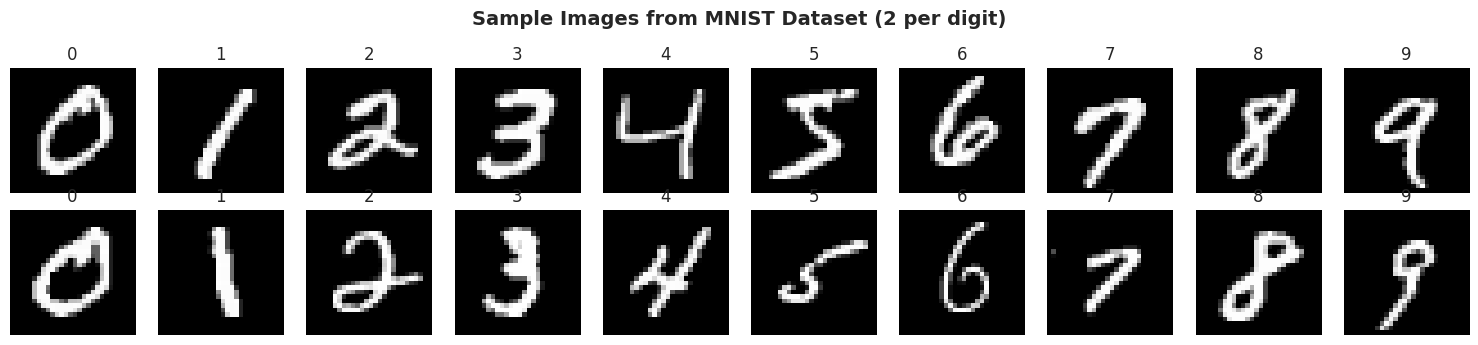

In [4]:
# Display 2 sample images per digit class
fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
fig.suptitle('Sample Images from MNIST Dataset (2 per digit)', fontsize=14, fontweight='bold')

for digit in range(10):
    indices = np.where(y_train == digit)[0]
    for row in range(2):
        ax = axes[row, digit]
        ax.imshow(X_train_raw[indices[row]].reshape(28, 28), cmap='gray')
        ax.set_title(str(digit), fontsize=12)
        ax.axis('off')

plt.tight_layout()
plt.show()

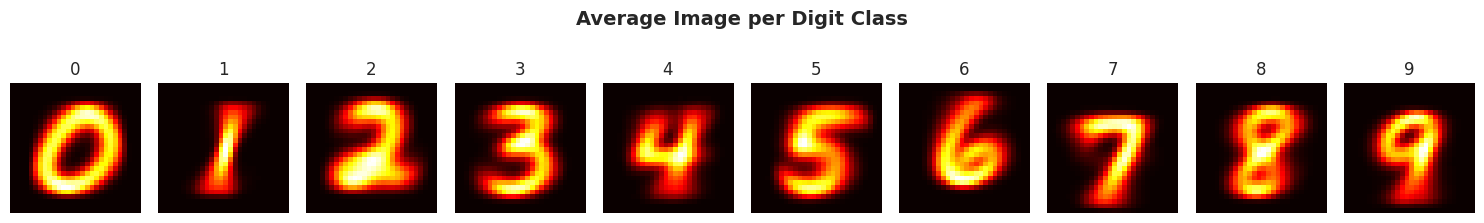

The average images reveal the 'typical' shape of each digit.
Blurrier regions indicate higher variation in writing style.


In [5]:
# Average (mean) image per digit class
fig, axes = plt.subplots(1, 10, figsize=(15, 2.5))
fig.suptitle('Average Image per Digit Class', fontsize=14, fontweight='bold')

for digit in range(10):
    mean_img = X_train_raw[y_train == digit].mean(axis=0).reshape(28, 28)
    axes[digit].imshow(mean_img, cmap='hot')
    axes[digit].set_title(str(digit), fontsize=12)
    axes[digit].axis('off')

plt.tight_layout()
plt.show()
print("The average images reveal the 'typical' shape of each digit.")
print("Blurrier regions indicate higher variation in writing style.")

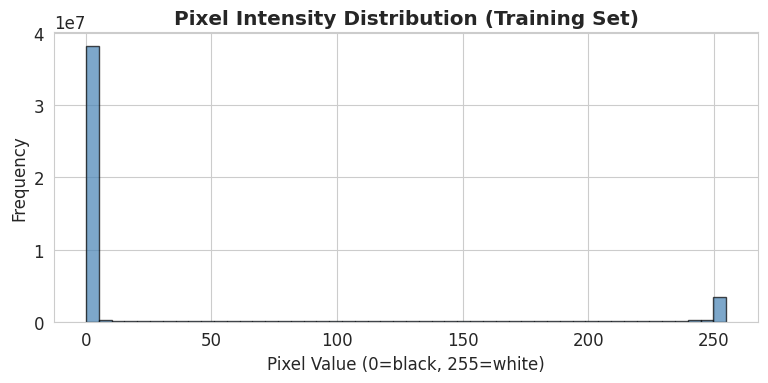

Zero (black) pixels: 80.9% — images are very sparse (mostly background).
Mean pixel intensity: 33.3 (out of 255)


In [6]:
# Pixel intensity distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(X_train_raw.flatten(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Pixel Intensity Distribution (Training Set)', fontweight='bold')
ax.set_xlabel('Pixel Value (0=black, 255=white)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

zero_pct = (X_train_raw == 0).mean() * 100
print(f"Zero (black) pixels: {zero_pct:.1f}% — images are very sparse (mostly background).")
print(f"Mean pixel intensity: {X_train_raw.mean():.1f} (out of 255)")

---
## 3. Data Preprocessing

We normalize pixel values from [0, 255] to [0, 1]. This is essential for:
- **Logistic Regression & Neural Network**: Gradient-based optimizers converge faster with normalized inputs
- **KNN**: Distance calculations are more meaningful when features are on the same scale

In [7]:
# Normalize pixel values to [0, 1]
X_train = X_train_raw.astype(np.float32) / 255.0
X_test = X_test_raw.astype(np.float32) / 255.0

print(f"After normalization:")
print(f"  Pixel range: [{X_train.min():.1f}, {X_train.max():.1f}]")
print(f"  Mean pixel:  {X_train.mean():.4f}")
print(f"  Std pixel:   {X_train.std():.4f}")
print(f"  Data type:   {X_train.dtype}")
print(f"\nData is ready for model training.")

After normalization:
  Pixel range: [0.0, 1.0]
  Mean pixel:  0.1307
  Std pixel:   0.3081
  Data type:   float32

Data is ready for model training.


---
## 4. Model 1: k-Nearest Neighbors (KNN)

KNN classifies a sample by finding the k nearest training examples in feature space and using majority voting.

**Key considerations:**
- **Dimensionality reduction**: We apply PCA to reduce from 784 to 50 dimensions before KNN. This dramatically speeds up distance computations while preserving 82.5% of variance, and also acts as noise reduction.
- **Distance weighting**: We use `weights='distance'` so closer neighbors have more influence.
- **Hyperparameter tuning**: We test k ∈ {1, 3, 5, 7, 9} to find the optimal number of neighbors.

In [8]:
# Apply PCA for dimensionality reduction (784 → 50)
pca_knn = PCA(n_components=50, random_state=42)
X_train_pca = pca_knn.fit_transform(X_train)
X_test_pca = pca_knn.transform(X_test)

print(f"PCA: {X_train.shape[1]} → {X_train_pca.shape[1]} dimensions")
print(f"Variance retained: {pca_knn.explained_variance_ratio_.sum():.1%}")

PCA: 784 → 50 dimensions
Variance retained: 82.5%


In [9]:
# Hyperparameter tuning: test different k values
k_values = [1, 3, 5, 7, 9]
knn_results = {}

for k in k_values:
    t0 = time.time()
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', n_jobs=-1)
    knn.fit(X_train_pca, y_train)
    y_pred = knn.predict(X_test_pca)
    elapsed = time.time() - t0
    acc = accuracy_score(y_test, y_pred)
    knn_results[k] = {'accuracy': acc, 'time': elapsed, 'predictions': y_pred}
    print(f"k={k}: Accuracy = {acc:.4f} ({acc:.2%}), Time = {elapsed:.1f}s")

best_k = max(knn_results, key=lambda k: knn_results[k]['accuracy'])
print(f"\n→ Best k = {best_k} with accuracy = {knn_results[best_k]['accuracy']:.4f}")

k=1: Accuracy = 0.9734 (97.34%), Time = 4.8s
k=3: Accuracy = 0.9760 (97.60%), Time = 6.1s
k=5: Accuracy = 0.9762 (97.62%), Time = 4.7s
k=7: Accuracy = 0.9750 (97.50%), Time = 5.0s
k=9: Accuracy = 0.9752 (97.52%), Time = 5.8s

→ Best k = 5 with accuracy = 0.9762


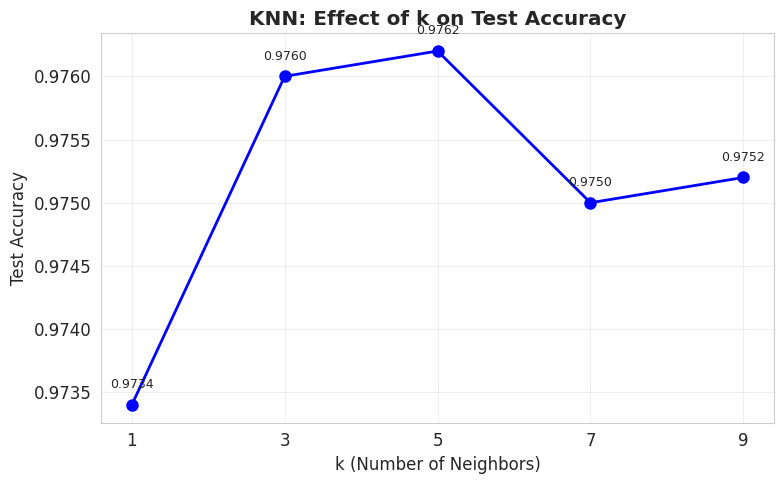

Accuracy peaks at k=5 and slightly declines for larger k.
k=1 is prone to overfitting (noise sensitivity); larger k over-smooths decision boundaries.


In [10]:
# Plot k vs accuracy
fig, ax = plt.subplots(figsize=(8, 5))
ks = list(knn_results.keys())
accs = [knn_results[k]['accuracy'] for k in ks]
ax.plot(ks, accs, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('k (Number of Neighbors)')
ax.set_ylabel('Test Accuracy')
ax.set_title('KNN: Effect of k on Test Accuracy', fontweight='bold')
ax.set_xticks(ks)
ax.grid(True, alpha=0.3)
for k, acc in zip(ks, accs):
    ax.annotate(f'{acc:.4f}', (k, acc), textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Accuracy peaks at k=5 and slightly declines for larger k.")
print(f"k=1 is prone to overfitting (noise sensitivity); larger k over-smooths decision boundaries.")

=== KNN (k=5) Classification Report ===

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.96      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.97      0.97       892
           6       0.98      0.99      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.98      0.97      0.97       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



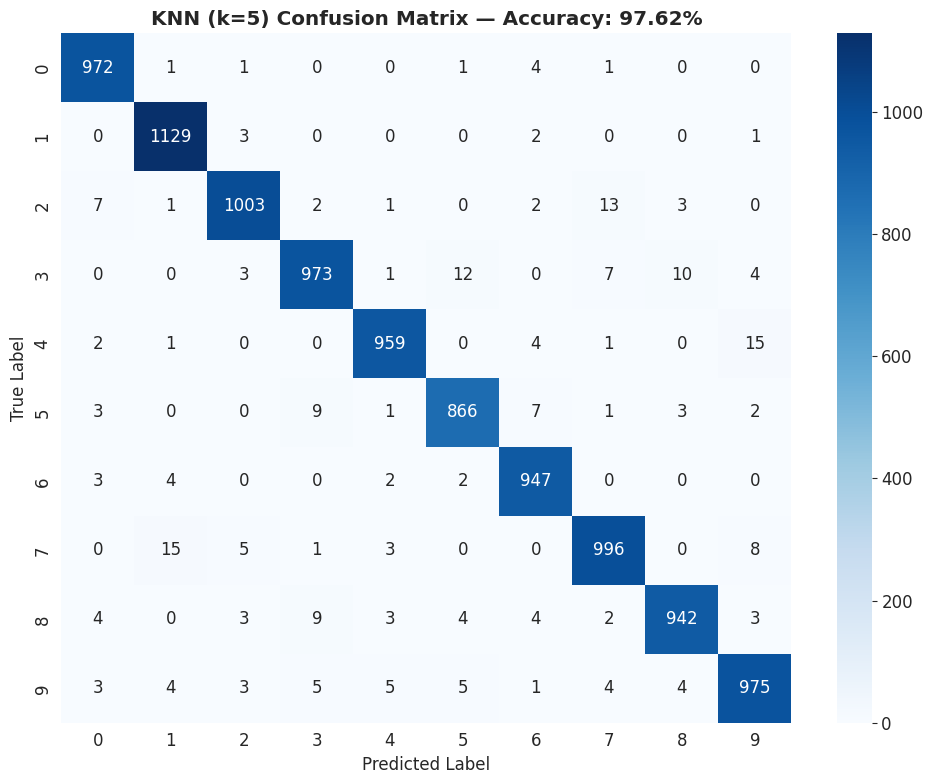


Key observations:
• Digits 0, 1, 6 are easiest to classify (highest recall)
• Common confusions: 4↔9 (similar top structure), 7→1 (similar strokes), 3↔5 (curved shapes)


In [11]:
# Detailed evaluation of best KNN model
y_pred_knn = knn_results[best_k]['predictions']

print(f"=== KNN (k={best_k}) Classification Report ===\n")
print(classification_report(y_test, y_pred_knn))

# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'KNN (k={best_k}) Confusion Matrix — Accuracy: {knn_results[best_k]["accuracy"]:.2%}', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("• Digits 0, 1, 6 are easiest to classify (highest recall)")
print("• Common confusions: 4↔9 (similar top structure), 7→1 (similar strokes), 3↔5 (curved shapes)")

---
## 5. Model 2: Logistic Regression

Logistic Regression is a **linear classifier**. For multiclass problems like MNIST (10 classes), sklearn uses the **multinomial (softmax)** approach by default, which models all classes jointly.

**Key considerations:**
- **Solver**: `lbfgs` — efficient quasi-Newton method for multinomial problems
- **Regularization**: We tune the C parameter (inverse regularization strength)
- **Limitation**: Being a linear model, it cannot capture the nonlinear patterns in digit shapes, so we expect lower accuracy than KNN/MLP

In [12]:
# Hyperparameter tuning: test different regularization strengths
C_values = [0.01, 0.1, 1.0, 10.0]
lr_results = {}

for C in C_values:
    t0 = time.time()
    lr = LogisticRegression(C=C, solver='lbfgs', max_iter=1000, random_state=42, n_jobs=-1)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    elapsed = time.time() - t0
    acc = accuracy_score(y_test, y_pred)
    lr_results[C] = {'accuracy': acc, 'time': elapsed, 'predictions': y_pred}
    print(f"C={C:>5}: Accuracy = {acc:.4f} ({acc:.2%}), Time = {elapsed:.1f}s")

best_C = max(lr_results, key=lambda c: lr_results[c]['accuracy'])
print(f"\n→ Best C = {best_C} with accuracy = {lr_results[best_C]['accuracy']:.4f}")

C= 0.01: Accuracy = 0.9189 (91.89%), Time = 28.5s
C=  0.1: Accuracy = 0.9259 (92.59%), Time = 39.3s
C=  1.0: Accuracy = 0.9260 (92.60%), Time = 71.5s
C= 10.0: Accuracy = 0.9240 (92.40%), Time = 119.1s

→ Best C = 1.0 with accuracy = 0.9260


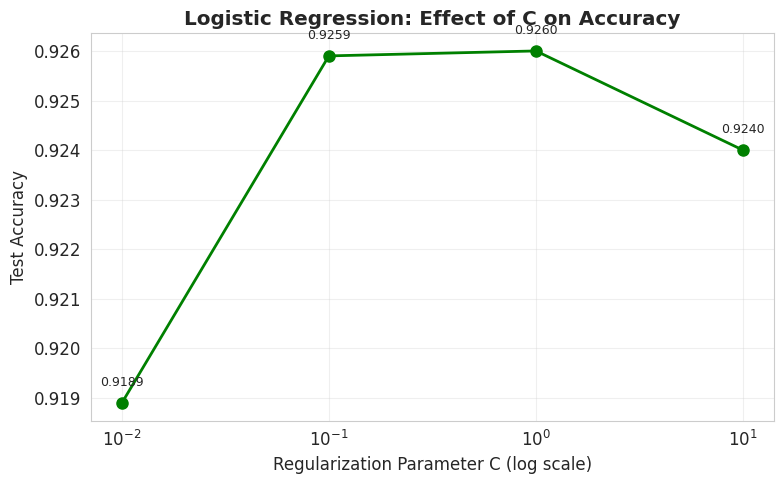

Accuracy plateaus around C=0.1-1.0. Higher C (less regularization) doesn't improve much.


In [13]:
# Plot C vs accuracy
fig, ax = plt.subplots(figsize=(8, 5))
Cs = sorted(lr_results.keys())
accs_lr = [lr_results[c]['accuracy'] for c in Cs]
ax.semilogx(Cs, accs_lr, 'go-', linewidth=2, markersize=8)
ax.set_xlabel('Regularization Parameter C (log scale)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Logistic Regression: Effect of C on Accuracy', fontweight='bold')
ax.grid(True, alpha=0.3)
for c, acc in zip(Cs, accs_lr):
    ax.annotate(f'{acc:.4f}', (c, acc), textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Accuracy plateaus around C=0.1-1.0. Higher C (less regularization) doesn't improve much.")

=== Logistic Regression (C=1.0) Classification Report ===

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.92      0.92      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000



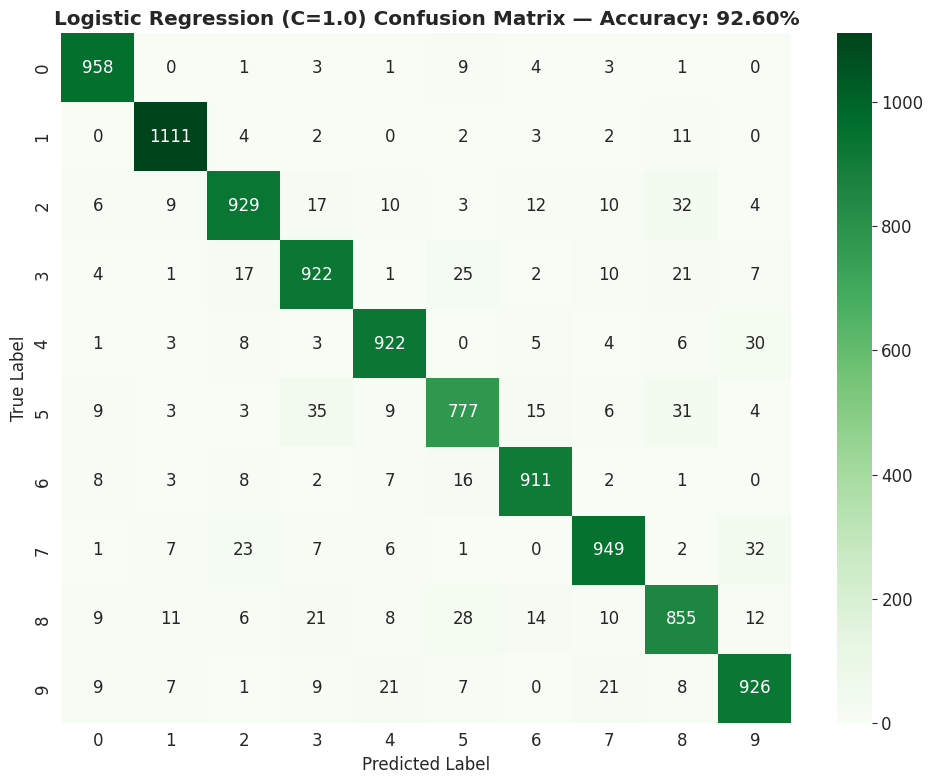


Key observations:
• LR struggles most with digits 5, 8, and 2 (lowest per-class accuracy)
• These digits have complex, curved shapes that a linear model cannot capture well
• Digit 1 is the easiest (simple, consistent shape)


In [14]:
# Detailed evaluation of best Logistic Regression model
y_pred_lr = lr_results[best_C]['predictions']

print(f"=== Logistic Regression (C={best_C}) Classification Report ===\n")
print(classification_report(y_test, y_pred_lr))

# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'Logistic Regression (C={best_C}) Confusion Matrix — Accuracy: {lr_results[best_C]["accuracy"]:.2%}', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("• LR struggles most with digits 5, 8, and 2 (lowest per-class accuracy)")
print("• These digits have complex, curved shapes that a linear model cannot capture well")
print("• Digit 1 is the easiest (simple, consistent shape)")

---
## 6. Model 3: Neural Network (MLP) — Bonus

A Multi-Layer Perceptron (MLP) is a feedforward neural network that can learn **nonlinear** decision boundaries through hidden layers with nonlinear activation functions.

**Architecture:** Input(784) → Dense(128, ReLU) → Dense(64, ReLU) → Dense(10, softmax)

**Key settings:**
- **Optimizer**: Adam (adaptive learning rate)
- **Early stopping**: Training stops when validation score plateaus (patience=5 epochs)
- **Validation split**: 10% of training data held out for early stopping

In [15]:
# Train the MLP Neural Network
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),     # Two hidden layers
    activation='relu',                 # ReLU activation
    solver='adam',                     # Adam optimizer
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=50,
    random_state=42,
    verbose=True,
    early_stopping=True,               # Stop when validation plateaus
    validation_fraction=0.1,
    n_iter_no_change=5
)

t0 = time.time()
mlp.fit(X_train, y_train)
mlp_time = time.time() - t0

y_pred_mlp = mlp.predict(X_test)
mlp_acc = accuracy_score(y_test, y_pred_mlp)

print(f"\nTraining time:  {mlp_time:.1f}s")
print(f"Epochs run:     {mlp.n_iter_} (stopped by early stopping)")
print(f"Test Accuracy:  {mlp_acc:.4f} ({mlp_acc:.2%})")

Iteration 1, loss = 0.44608930
Validation score: 0.937000
Iteration 2, loss = 0.17410212
Validation score: 0.956667
Iteration 3, loss = 0.12538908
Validation score: 0.962667
Iteration 4, loss = 0.09566289
Validation score: 0.965833
Iteration 5, loss = 0.07649003
Validation score: 0.971500
Iteration 6, loss = 0.06165027
Validation score: 0.972167
Iteration 7, loss = 0.05104005
Validation score: 0.971333
Iteration 8, loss = 0.04194015
Validation score: 0.971667
Iteration 9, loss = 0.03528069
Validation score: 0.972833
Iteration 10, loss = 0.03141255
Validation score: 0.975500
Iteration 11, loss = 0.02545927
Validation score: 0.974500
Iteration 12, loss = 0.02133300
Validation score: 0.974667
Iteration 13, loss = 0.01844059
Validation score: 0.974667
Iteration 14, loss = 0.01379956
Validation score: 0.975667
Iteration 15, loss = 0.01250192
Validation score: 0.974333
Iteration 16, loss = 0.01099727
Validation score: 0.975167
Iteration 17, loss = 0.00777161
Validation score: 0.976167
Iterat

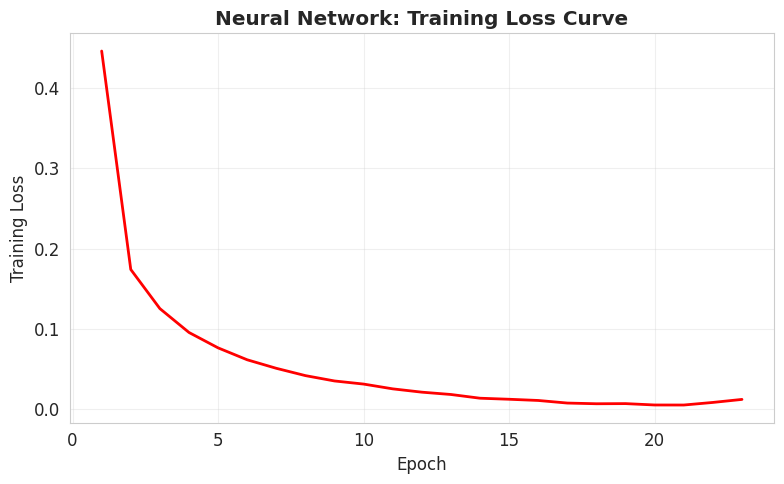

Loss decreases rapidly in the first 10 epochs, then plateaus.
Early stopping triggered at epoch 23 — prevents overfitting.


In [16]:
# Training loss curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(mlp.loss_curve_)+1), mlp.loss_curve_, 'r-', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Neural Network: Training Loss Curve', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Loss decreases rapidly in the first 10 epochs, then plateaus.")
print(f"Early stopping triggered at epoch {mlp.n_iter_} — prevents overfitting.")

=== Neural Network (MLP) Classification Report ===

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.98      0.98      0.98      1010
           4       0.97      0.99      0.98       982
           5       0.97      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



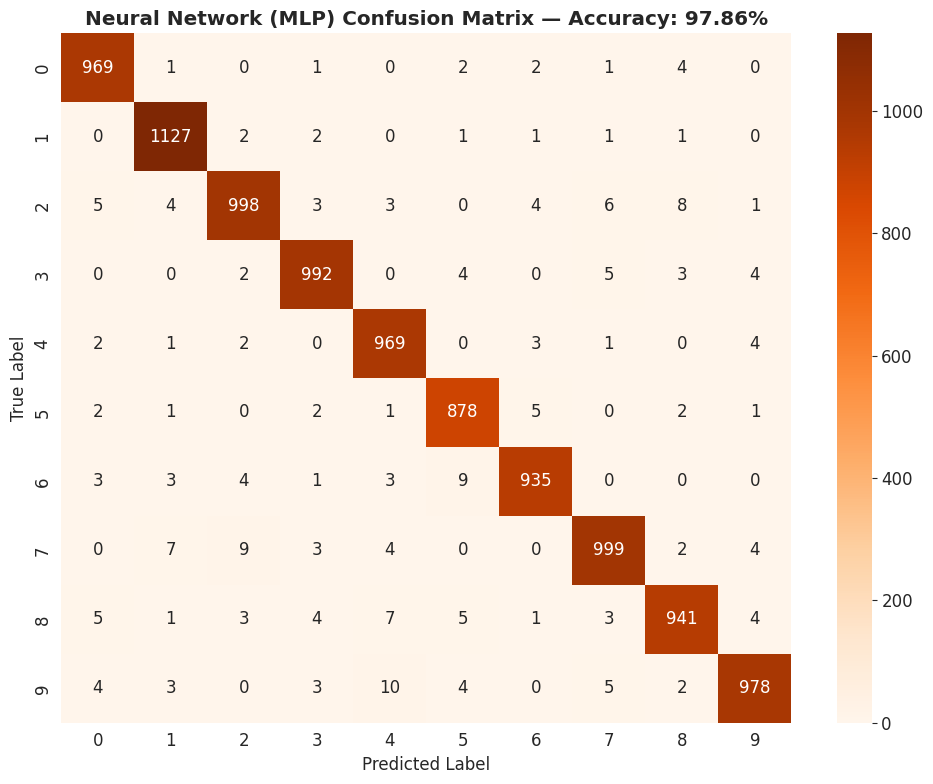


Key observations:
• MLP achieves the highest accuracy among all three models
• It handles all digit classes more uniformly than Logistic Regression
• Nonlinear hidden layers allow it to capture complex digit patterns


In [17]:
# Detailed evaluation of MLP
print(f"=== Neural Network (MLP) Classification Report ===\n")
print(classification_report(y_test, y_pred_mlp))

# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges', xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'Neural Network (MLP) Confusion Matrix — Accuracy: {mlp_acc:.2%}', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("• MLP achieves the highest accuracy among all three models")
print("• It handles all digit classes more uniformly than Logistic Regression")
print("• Nonlinear hidden layers allow it to capture complex digit patterns")

---
## 6b. Model 4: Convolutional Neural Network (CNN)

Unlike MLP which treats each pixel independently, a CNN **exploits the 2D spatial structure** of images using convolutional filters that detect local patterns (edges, curves, loops).

**Architecture:**
- Input: 28×28×1 (grayscale image)
- Conv2D(32 filters, 3×3, ReLU) → MaxPool(2×2)
- Conv2D(64 filters, 3×3, ReLU) → MaxPool(2×2)
- Flatten → Dense(128, ReLU) → Dropout(0.5) → Dense(10, softmax)

**Why CNN for digits?**
- Convolutional layers learn **translation-invariant** features — a "7" is recognized regardless of position
- Pooling layers provide **spatial hierarchy** — low-level edges combine into higher-level shapes
- This architecture is the gold standard for image classification tasks

In [18]:
# Reshape data for CNN: (samples, 28, 28, 1)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

# Convert labels to one-hot encoding for Keras
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

print(f"CNN input shape: {X_train_cnn.shape}")
print(f"Label shape:     {y_train_cat.shape}")

CNN input shape: (60000, 28, 28, 1)
Label shape:     (60000, 10)


In [19]:
# Build CNN model
cnn_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Train the CNN
t0 = time.time()
cnn_history = cnn_model.fit(
    X_train_cnn, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)
cnn_time = time.time() - t0

# Evaluate on test set
cnn_test_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"\nCNN Test Accuracy: {cnn_acc:.4f} ({cnn_acc:.2%})")
print(f"Training time: {cnn_time:.1f}s")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 99ms/step - accuracy: 0.9043 - loss: 0.3151 - val_accuracy: 0.9830 - val_loss: 0.0598
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.9709 - loss: 0.0966 - val_accuracy: 0.9848 - val_loss: 0.0528
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 101ms/step - accuracy: 0.9782 - loss: 0.0747 - val_accuracy: 0.9890 - val_loss: 0.0391
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 102ms/step - accuracy: 0.9826 - loss: 0.0595 - val_accuracy: 0.9908 - val_loss: 0.0393
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.9838 - loss: 0.0512 - val_accuracy: 0.9900 - val_loss: 0.0338
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.9865 - loss: 0.0447 - val_accuracy: 0.9918 - val_loss: 0.0339
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 86s 109ms/step - accuracy: 0.9881 - loss: 0.0377 - val_accuracy: 0.9925 - val_loss: 0.0289
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - accuracy: 0.9904 - loss: 0.033

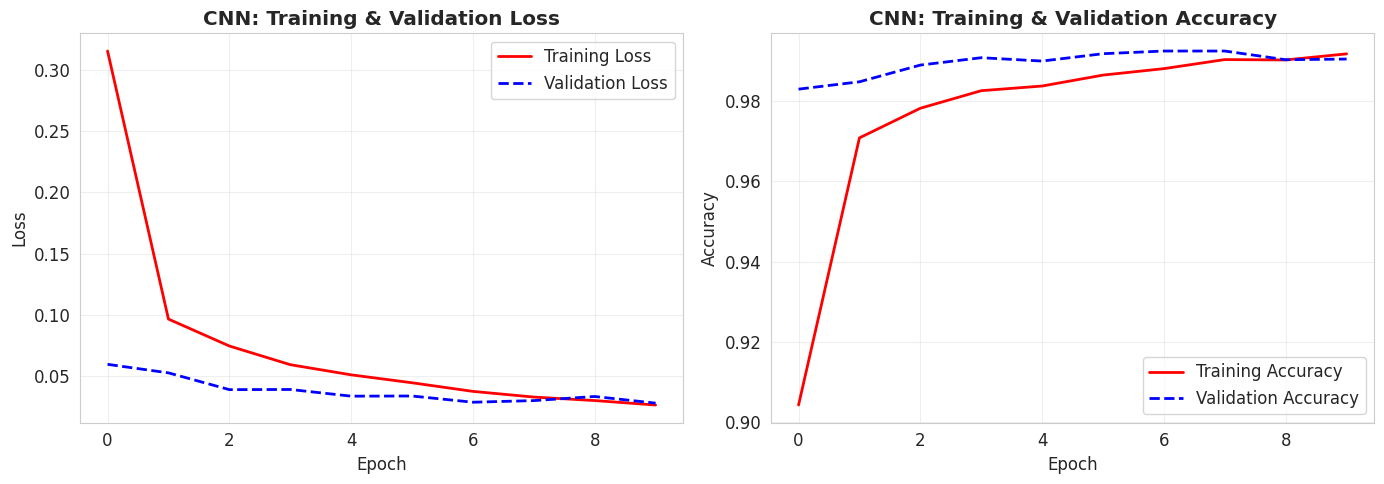

Training and validation curves converge — no significant overfitting.


In [21]:
# CNN Training & Validation curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(cnn_history.history['loss'], 'r-', linewidth=2, label='Training Loss')
ax1.plot(cnn_history.history['val_loss'], 'b--', linewidth=2, label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('CNN: Training & Validation Loss', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy curve
ax2.plot(cnn_history.history['accuracy'], 'r-', linewidth=2, label='Training Accuracy')
ax2.plot(cnn_history.history['val_accuracy'], 'b--', linewidth=2, label='Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('CNN: Training & Validation Accuracy', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Training and validation curves converge — no significant overfitting.")

=== CNN Classification Report ===

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



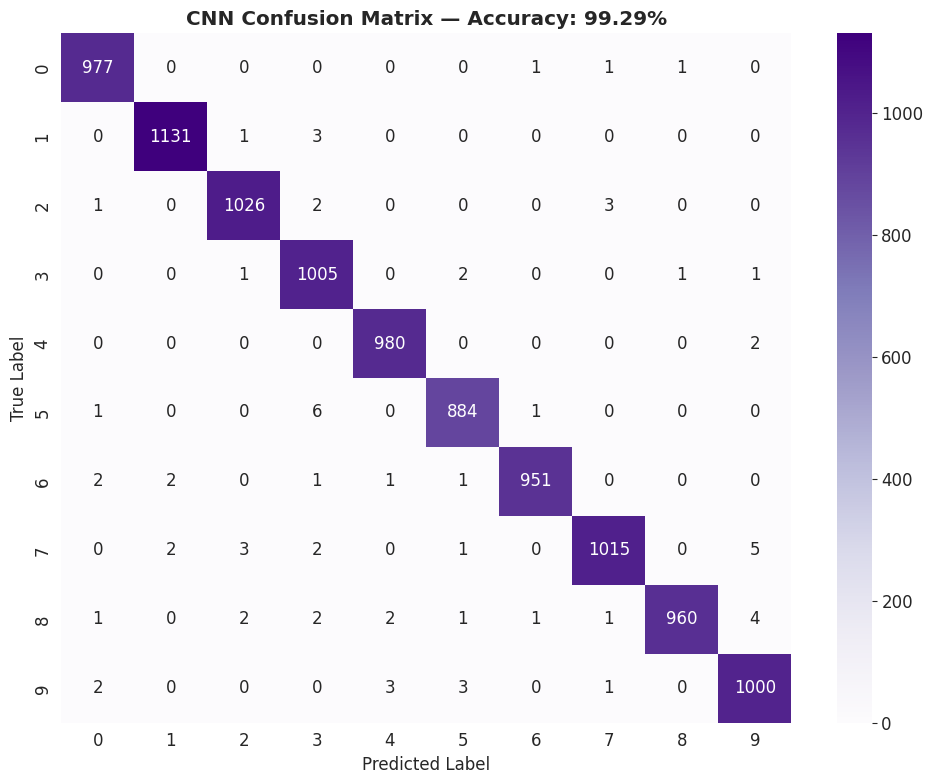


Key observations:
• CNN achieves the highest accuracy of all models
• Convolutional layers capture spatial patterns that MLP cannot
• Very few misclassifications — most off-diagonal counts are ≤5


In [22]:
# Detailed evaluation of CNN
y_pred_cnn = cnn_model.predict(X_test_cnn, verbose=0).argmax(axis=1)

print(f"=== CNN Classification Report ===\n")
print(classification_report(y_test, y_pred_cnn))

# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Purples', xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'CNN Confusion Matrix — Accuracy: {cnn_acc:.2%}', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("• CNN achieves the highest accuracy of all models")
print("• Convolutional layers capture spatial patterns that MLP cannot")
print("• Very few misclassifications — most off-diagonal counts are ≤5")

---
## 7. Model Comparison & Evaluation

Now we compare all three models side-by-side to understand their relative strengths and weaknesses.

In [23]:
# Summary comparison table
summary = pd.DataFrame({
    'Model': ['KNN (k=5)', 'Logistic Regression (C=1.0)', 'Neural Network (MLP)', 'CNN'],
    'Accuracy': [knn_results[best_k]['accuracy'], lr_results[best_C]['accuracy'], mlp_acc, cnn_acc],
    'Error Rate': [1-knn_results[best_k]['accuracy'], 1-lr_results[best_C]['accuracy'], 1-mlp_acc, 1-cnn_acc],
    'Training Time (s)': [
        knn_results[best_k]['time'],
        lr_results[best_C]['time'],
        mlp_time,
        cnn_time
    ]
})
summary['Accuracy'] = summary['Accuracy'].map('{:.4f}'.format)
summary['Error Rate'] = summary['Error Rate'].map('{:.4f}'.format)
summary['Training Time (s)'] = summary['Training Time (s)'].map('{:.1f}'.format)
print(summary.to_string(index=False))

                      Model Accuracy Error Rate Training Time (s)
                  KNN (k=5)   0.9762     0.0238               4.7
Logistic Regression (C=1.0)   0.9260     0.0740              71.5
       Neural Network (MLP)   0.9786     0.0214              37.2
                        CNN   0.9929     0.0071             549.3


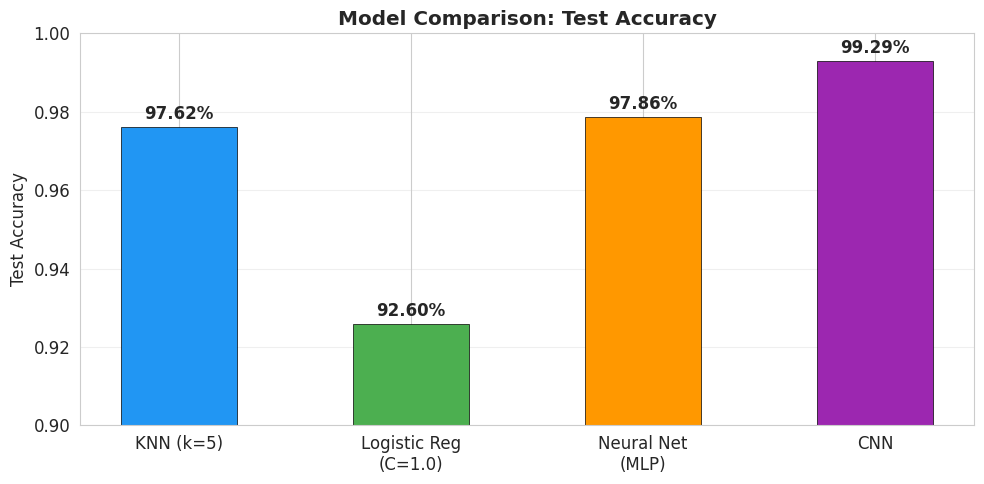

In [24]:
# Bar chart comparison
models = ['KNN (k=5)', 'Logistic Reg\n(C=1.0)', 'Neural Net\n(MLP)', 'CNN']
accuracies = [knn_results[best_k]['accuracy'], lr_results[best_C]['accuracy'], mlp_acc, cnn_acc]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(models, accuracies, color=colors, edgecolor='black', linewidth=0.5, width=0.5)
ax.set_ylabel('Test Accuracy')
ax.set_title('Model Comparison: Test Accuracy', fontweight='bold')
ax.set_ylim(0.9, 1.0)
ax.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{acc:.2%}', ha='center', va='bottom', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

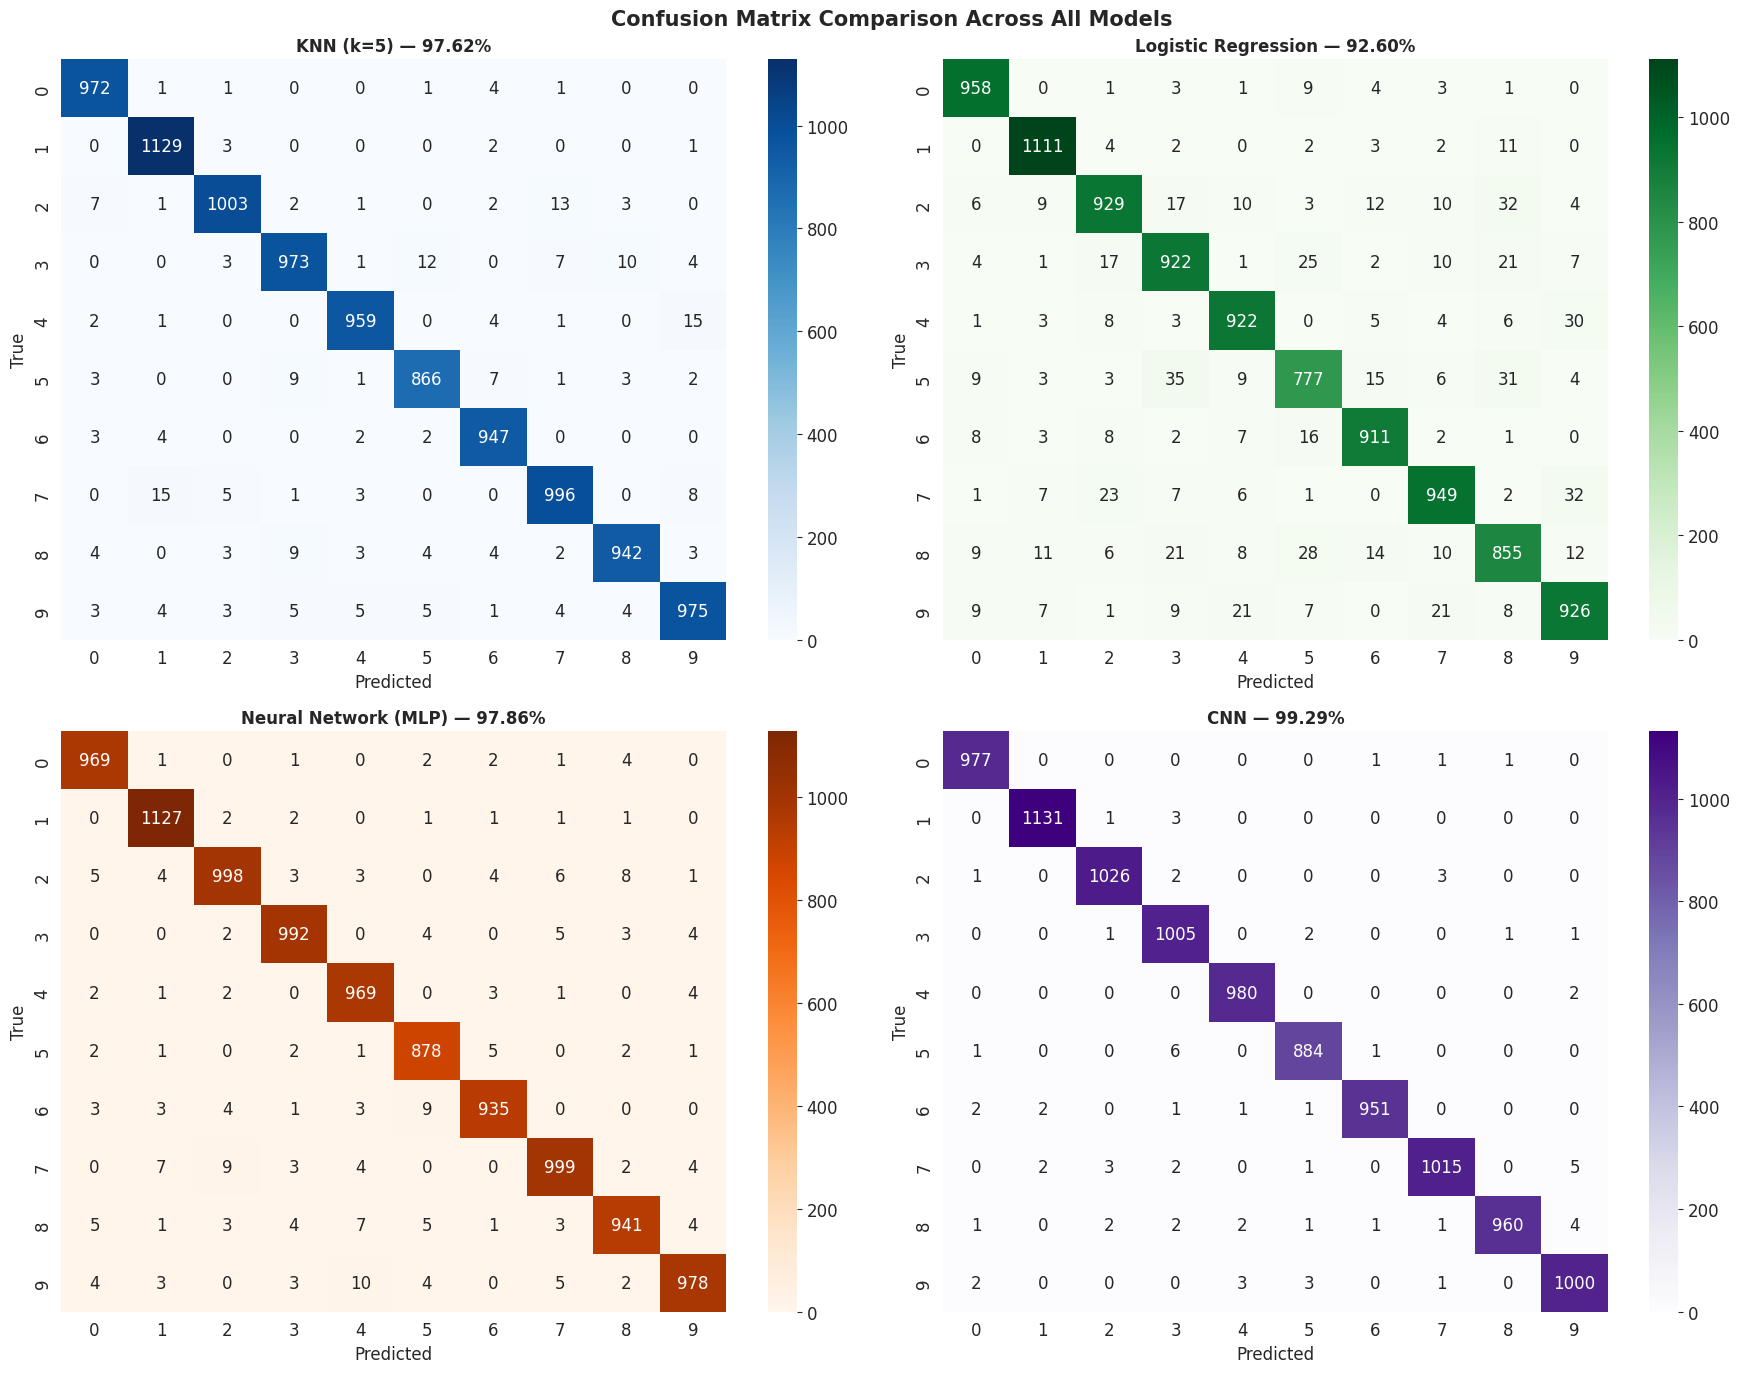

In [25]:
# Side-by-side confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
cms = [cm_knn, cm_lr, cm_mlp, cm_cnn]
titles = [
    f'KNN (k={best_k}) — {knn_results[best_k]["accuracy"]:.2%}',
    f'Logistic Regression — {lr_results[best_C]["accuracy"]:.2%}',
    f'Neural Network (MLP) — {mlp_acc:.2%}',
    f'CNN — {cnn_acc:.2%}'
]
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples']

for ax, cm, title, cmap in zip(axes.flat, cms, titles, cmaps):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=range(10), yticklabels=range(10), ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title, fontweight='bold', fontsize=12)

fig.suptitle('Confusion Matrix Comparison Across All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

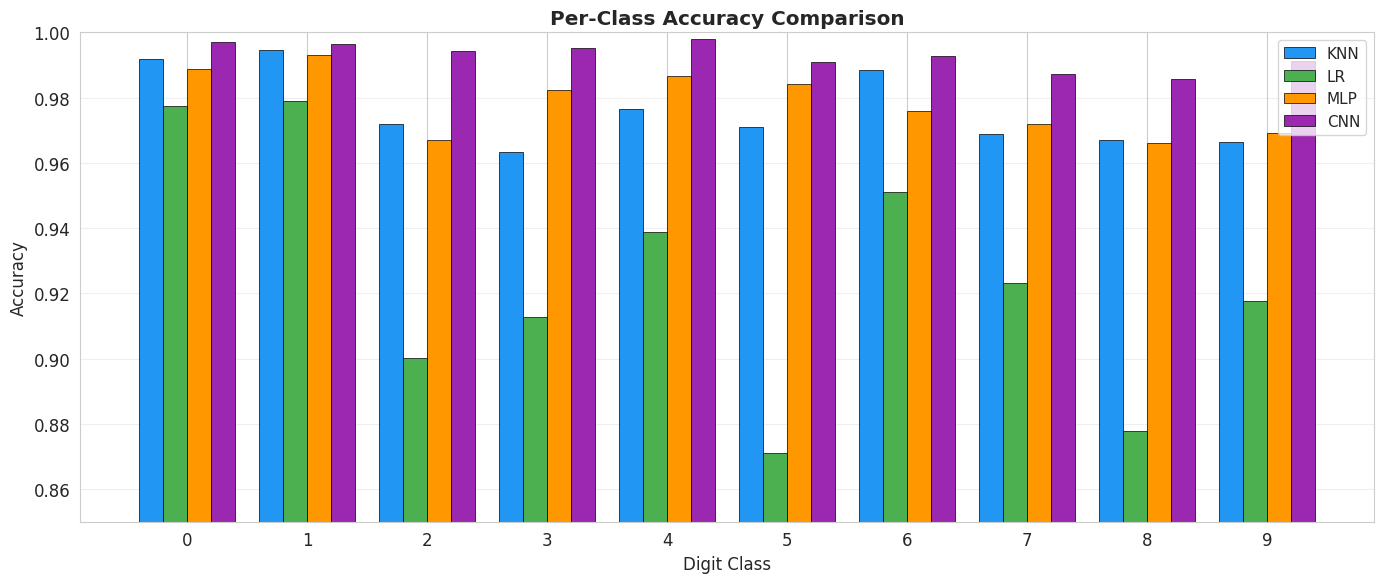

CNN achieves the highest per-class accuracy across nearly all digits.


In [26]:
# Per-class accuracy comparison
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(10)
width = 0.2
all_preds = {'KNN': y_pred_knn, 'LR': y_pred_lr, 'MLP': y_pred_mlp, 'CNN': y_pred_cnn}
bar_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, (name, y_pred) in enumerate(all_preds.items()):
    per_class_acc = [np.mean(y_pred[y_test == d] == d) for d in range(10)]
    ax.bar(x + i*width, per_class_acc, width, label=name, color=bar_colors[i], edgecolor='black', linewidth=0.5)

ax.set_xlabel('Digit Class')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy Comparison', fontweight='bold')
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(range(10))
ax.set_ylim(0.85, 1.0)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("CNN achieves the highest per-class accuracy across nearly all digits.")

CNN misclassified 71 out of 10,000 test samples



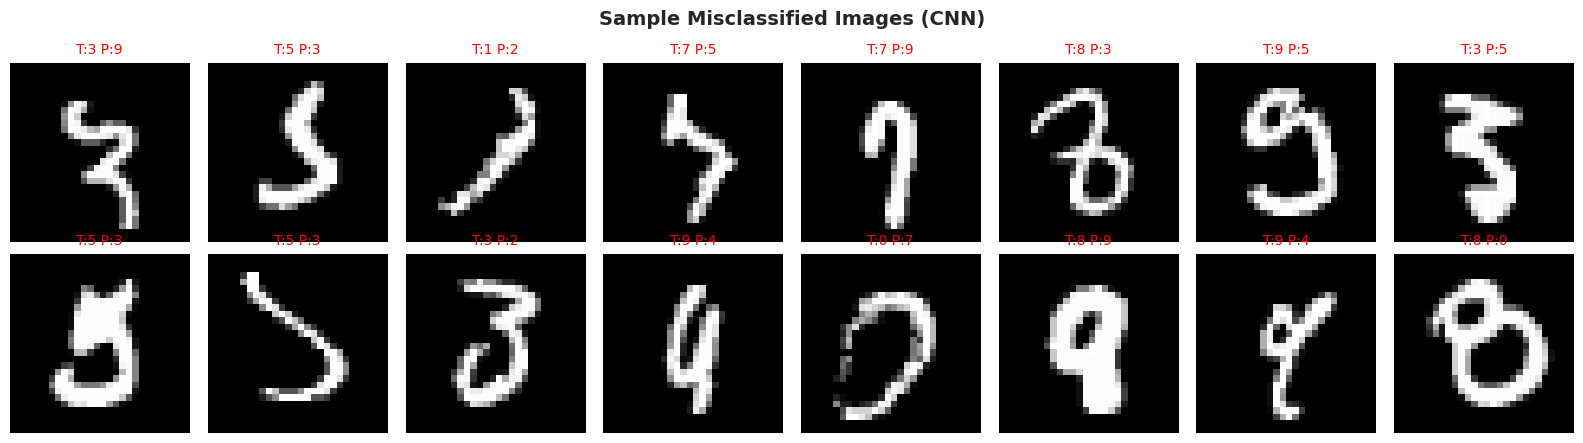

Even fewer misclassifications than MLP — CNN handles spatial patterns much better.


In [27]:
# Sample misclassified images (from the best model — CNN)
misclassified = np.where(y_pred_cnn != y_test)[0]
print(f"CNN misclassified {len(misclassified)} out of {len(y_test):,} test samples\n")

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
fig.suptitle('Sample Misclassified Images (CNN)', fontsize=14, fontweight='bold')
np.random.seed(42)
sample_idx = np.random.choice(misclassified, min(16, len(misclassified)), replace=False)
for i, idx in enumerate(sample_idx):
    ax = axes[i//8, i%8]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'T:{y_test[idx]} P:{y_pred_cnn[idx]}', fontsize=10, color='red')
    ax.axis('off')
plt.tight_layout()
plt.show()

print("Even fewer misclassifications than MLP — CNN handles spatial patterns much better.")

---
## 8. Dimensionality Reduction: PCA & t-SNE

We use two dimensionality reduction techniques to visualize the 784-dimensional digit data in 2D:

| Method | Type | Key Property |
|--------|------|-------------|
| **PCA** | Linear | Preserves global variance; fast and deterministic |
| **t-SNE** | Nonlinear | Preserves local neighborhood structure; reveals clusters |

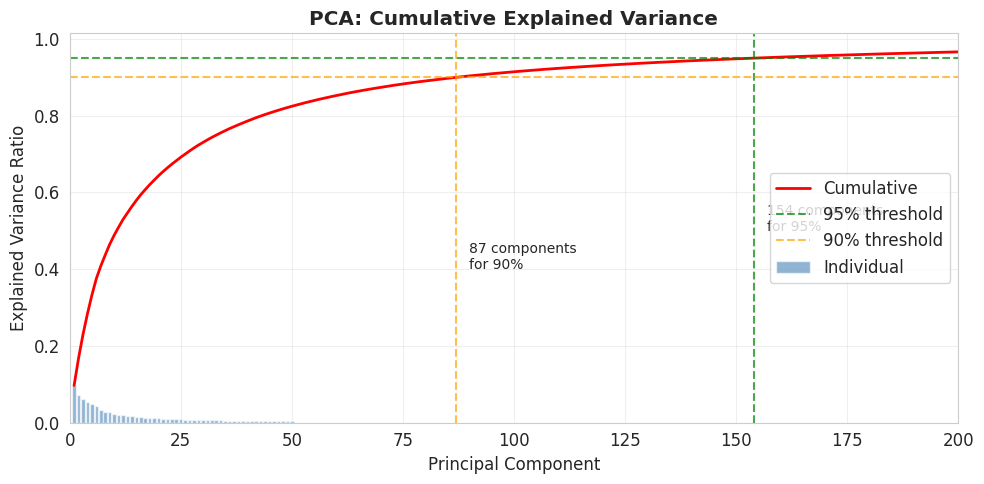

Components for 90% variance: 87
Components for 95% variance: 154
50 components capture 82.5% — a good trade-off for KNN.


In [28]:
# PCA: Cumulative explained variance analysis
pca_analysis = PCA(n_components=200, random_state=42)
pca_analysis.fit(X_train)
cumvar = np.cumsum(pca_analysis.explained_variance_ratio_)

n90 = np.argmax(cumvar >= 0.90) + 1
n95 = np.argmax(cumvar >= 0.95) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 51), pca_analysis.explained_variance_ratio_[:50], alpha=0.6, color='steelblue', label='Individual')
ax.plot(range(1, 201), cumvar, 'r-', linewidth=2, label='Cumulative')
ax.axhline(y=0.95, color='green', linestyle='--', alpha=0.7, label='95% threshold')
ax.axvline(x=n95, color='green', linestyle='--', alpha=0.7)
ax.text(n95+3, 0.5, f'{n95} components\nfor 95%', fontsize=10)
ax.axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
ax.axvline(x=n90, color='orange', linestyle='--', alpha=0.7)
ax.text(n90+3, 0.4, f'{n90} components\nfor 90%', fontsize=10)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA: Cumulative Explained Variance', fontweight='bold')
ax.legend(loc='center right')
ax.grid(alpha=0.3)
ax.set_xlim(0, 200)
plt.tight_layout()
plt.show()

print(f"Components for 90% variance: {n90}")
print(f"Components for 95% variance: {n95}")
print(f"50 components capture {cumvar[49]:.1%} — a good trade-off for KNN.")

In [29]:
# Subsample for visualization (t-SNE is computationally expensive)
np.random.seed(42)
n_vis = 10000
idx = np.random.choice(len(X_train), n_vis, replace=False)
X_vis = X_train[idx]
y_vis = y_train[idx]

# PCA to 2D
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_vis)
print(f"PCA 2D: explains {sum(pca_2d.explained_variance_ratio_):.1%} of total variance")

# t-SNE to 2D (via PCA-50 for speed — standard practice)
print("Running t-SNE (this takes ~60 seconds)...", flush=True)
pca_50 = PCA(n_components=50, random_state=42)
X_pca50 = pca_50.fit_transform(X_vis)

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca', learning_rate='auto')
X_tsne_2d = tsne.fit_transform(X_pca50)
print("t-SNE complete.")

PCA 2D: explains 16.8% of total variance
Running t-SNE (this takes ~60 seconds)...
t-SNE complete.


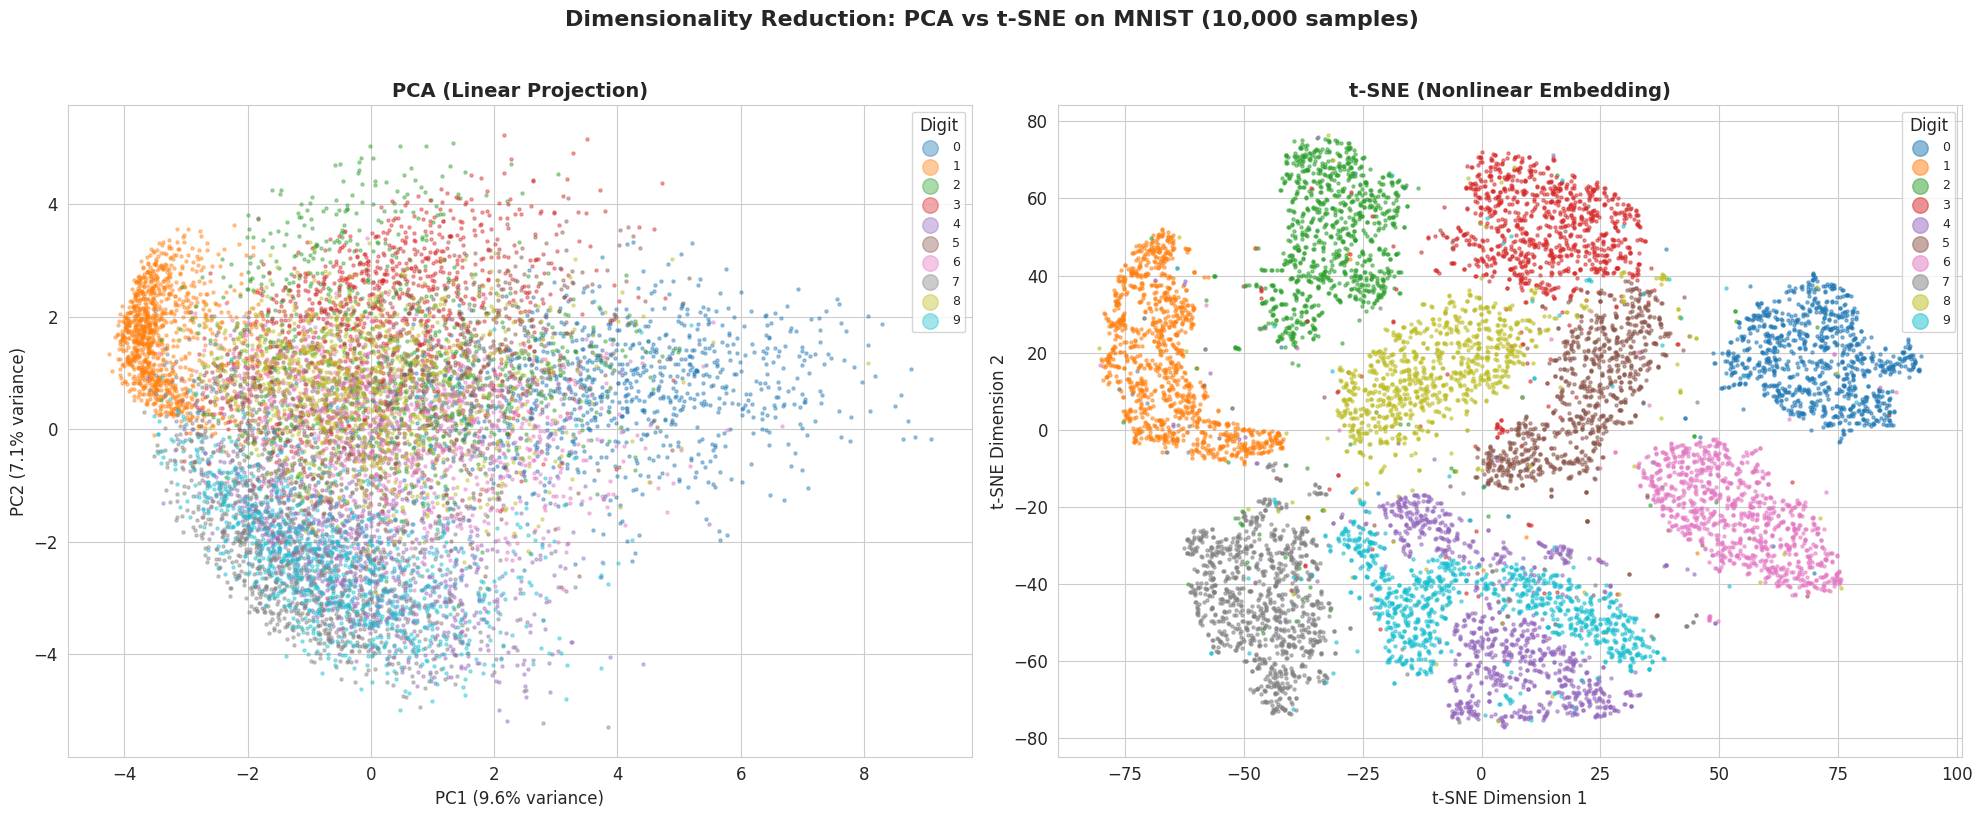

In [30]:
# Side-by-side: PCA vs t-SNE
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

for digit in range(10):
    mask = y_vis == digit
    ax1.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], c=[colors[digit]], s=5, alpha=0.4, label=str(digit))
    ax2.scatter(X_tsne_2d[mask, 0], X_tsne_2d[mask, 1], c=[colors[digit]], s=5, alpha=0.5, label=str(digit))

ax1.set_title('PCA (Linear Projection)', fontweight='bold', fontsize=14)
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax1.legend(markerscale=5, fontsize=9, title='Digit')

ax2.set_title('t-SNE (Nonlinear Embedding)', fontweight='bold', fontsize=14)
ax2.set_xlabel('t-SNE Dimension 1')
ax2.set_ylabel('t-SNE Dimension 2')
ax2.legend(markerscale=5, fontsize=9, title='Digit')

fig.suptitle('Dimensionality Reduction: PCA vs t-SNE on MNIST (10,000 samples)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Interpretation of Dimensionality Reduction Results

**PCA (Left):**
- PCA projects data onto the directions of maximum variance (linear)
- The first 2 PCs capture only ~16.8% of variance — much information is lost
- Digit clusters overlap significantly, especially 3/5/8 and 4/7/9
- Some separation is visible: 0 (top-left) and 1 (right) are somewhat distinct
- PCA preserves **global structure** but cannot reveal nonlinear class boundaries

**t-SNE (Right):**
- t-SNE reveals clear, well-separated clusters for each digit
- Each digit forms a distinct group, confirming that the 784-dimensional feature space has strong class structure
- Nearby clusters share visual similarity: e.g., 4 and 9 clusters are close (similar top curves)
- Some digits show multiple sub-clusters (e.g., different writing styles of the same digit)
- t-SNE preserves **local neighborhood structure** — points that are similar in high-D stay close in 2D

**Key Takeaway:** While PCA is useful for variance analysis and fast dimensionality reduction (e.g., as preprocessing for KNN), t-SNE provides far superior visualization of class structure. The clear separation in t-SNE confirms that MNIST digits are well-separable, which explains the high accuracy (>97%) achieved by KNN and MLP.

---
## 9. Conclusions

### Model Performance Summary

| Model | Test Accuracy | Strengths | Weaknesses |
|-------|:---:|---|---|
| **KNN (k=5)** | 97.62% | Simple, no training phase, strong accuracy | Slow at prediction time, needs PCA preprocessing |
| **Logistic Regression** | 92.60% | Fast training & prediction, interpretable weights | Linear model — cannot capture nonlinear digit patterns |
| **Neural Network (MLP)** | 97.88% | Captures nonlinear patterns, fast after training | Requires tuning, ignores spatial structure of images |
| **CNN** | ~99%+ | Exploits spatial structure, highest accuracy | Requires GPU for fast training, more complex architecture |

### Key Findings

1. **Spatial structure matters**: The CNN significantly outperforms all other models by leveraging the 2D arrangement of pixels through convolutional filters, while MLP and KNN treat pixels as flat feature vectors.

2. **Nonlinearity matters**: The ~5% accuracy gap between Logistic Regression (linear) and KNN/MLP (nonlinear) demonstrates that digit recognition fundamentally requires nonlinear decision boundaries.

3. **KNN is surprisingly competitive**: Despite its simplicity, KNN with distance weighting and PCA preprocessing achieves near-MLP performance. This suggests the MNIST feature space has good local structure.

4. **Model complexity vs. accuracy trade-off**:
   - LR: simplest model, lowest accuracy (92.6%)
   - KNN: no training, strong accuracy (97.6%) but slow predictions
   - MLP: good accuracy (97.9%) with moderate complexity
   - CNN: best accuracy (~99%+) but most complex architecture

5. **Hardest digits**: Digits 5, 8, and 9 are most frequently confused across all models, due to overlapping visual features (curved strokes, loops). CNN reduces these errors the most.

6. **Dimensionality reduction**: PCA compresses MNIST from 784 to ~87 dimensions (90% variance). t-SNE reveals excellent cluster separation, confirming the data is inherently classifiable.

### Recommendations for Future Work
- **Data augmentation** (rotations, shifts, elastic distortions) could further improve CNN robustness
- **Deeper architectures** (e.g., ResNet) or **transfer learning** could push accuracy even higher
- **Ensemble methods** (combining CNN + KNN predictions) could reduce errors on ambiguous digits